# Cohort Data Dictionary

Describes every column in `data/clean/cohort_cleaned.csv`.

- **Rows:** 18,731 participant-nights
- **Participants:** 98
- **Columns:** 21

## What one row represents

Each row is one participant on one date. The date is the morning the participant woke up. The row holds that night's sleep and recovery measurements, together with the activity and stress from the day that led into that night.

```
 Oct 4 daytime ─────────────── Oct 4 evening ──── night ──── Oct 5 morning
 [ steps, activity, stress ]                 [ sleep, HRV, resting heart rate ]

                      all stored on the row dated Oct 5
```

## Columns

### Identifiers

| Column | Meaning | Unit |
|---|---|---|
| `participant_id` | Anonymous code for each participant (P1 to P98), replacing the original ID | text |
| `calendarDate` | The date of the morning the participant woke up | date |
| `cohort` | Generic label for the program group the participant was enrolled in (`cohort_01` to `cohort_08`) | text |

### The night

| Column | Meaning | Unit | Source file |
|---|---|---|---|
| `durationInMs` | Total time asleep (deep + light + REM), not counting awake time | milliseconds | Sleep summary |
| `deepSleepDurationInMs` | Time in deep sleep | milliseconds | Sleep summary |
| `lightSleepDurationInMs` | Time in light sleep | milliseconds | Sleep summary |
| `remSleepInMs` | Time in REM sleep | milliseconds | Sleep summary |
| `awakeDurationInMs` | Time awake during the sleep period | milliseconds | Sleep summary |
| `overallSleepScore` | Garmin's overall rating of the night | score, 0 to 100 | Sleep summary |
| `lastNightAvg` | Average heart rate variability across the night | milliseconds | HRV summary |
| `lastNight5MinHigh` | Highest 5-minute average heart rate variability during the night | milliseconds | HRV summary |
| `restingHeartRateInBeatsPerMinute` | Resting heart rate for the wake-up date, measured mostly during sleep | beats per minute | Daily summary |
| `minHeartRateInBeatsPerMinute` | Lowest heart rate recorded on the wake-up date, usually reached during sleep | beats per minute | Daily summary |

### The day before the night

These columns come from the daily summary of the previous calendar date. They were moved forward one date so that each day lines up with the night that followed it.

| Column | Meaning | Unit | Source file |
|---|---|---|---|
| `maxHeartRateInBeatsPerMinute` | Highest heart rate recorded that day | beats per minute | Daily summary |
| `averageStressInStressLevel` | Average of Garmin's stress score across that day | score, 0 to 100 | Daily summary |
| `maxStressInStressLevel` | Highest stress score recorded that day | score, 0 to 100 | Daily summary |
| `steps` | Total steps that day | count | Daily summary |
| `activeKilocalories` | Calories burned through activity that day | kilocalories | Daily summary |
| `bmrKilocalories` | Calories burned at rest that day (basal metabolic rate) | kilocalories | Daily summary |
| `moderateIntensityDurationInMs` | Time in moderate-intensity activity that day | milliseconds | Daily summary |
| `vigorousIntensityDurationInMs` | Time in vigorous-intensity activity that day | milliseconds | Daily summary |

## Notes

- **Source:** Garmin data from Elpis Alliance participants, exported through LabFront as sleep summary, HRV summary, and daily summary files.
- **Date convention:** Garmin dates a night's sleep by the wake-up morning. This was checked against the sleep start times in the raw export.
- **De-identification:** Participant IDs and cohort names were replaced with generic labels before the data entered this repository.
- **Repeat enrollment:** 28 participants were enrolled in two cohorts. Their duplicate days were removed, and each appears under one of their two cohort labels.
- **Cleaning rule:** Only missing or impossible values were removed (blank values, invalid stress or HRV readings, partial days, and days with no steps recorded). Unusual but possible values, such as very short nights, were kept.
- **Intensity minutes:** Garmin estimates moderate and vigorous activity from heart rate, so these columns reflect effort relative to the wearer's own heart rate, not a fixed pace or workload.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition, metrics

In [2]:
cohort = pd.read_csv("../data/clean/cohort_cleaned.csv")
print("shape:", cohort.shape)

features = ["deepSleepDurationInMs", "lightSleepDurationInMs", "remSleepInMs",
            "awakeDurationInMs", "lastNightAvg", "restingHeartRateInBeatsPerMinute",
            "averageStressInStressLevel", "steps", "vigorousIntensityDurationInMs"]
cohort_numeric = cohort[features]

cohort_scaled = StandardScaler().fit_transform(cohort_numeric)
cohort_scaled = pd.DataFrame(cohort_scaled, columns=features)
cohort_scaled.head()

shape: (18731, 21)


,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,lastNightAvg,restingHeartRateInBeatsPerMinute,averageStressInStressLevel,steps,vigorousIntensityDurationInMs
0,-0.437534,0.593595,0.768266,-0.820246,2.124708,-0.937434,0.579124,-1.001291,-0.429300
1,-0.368617,-0.016940,-0.678965,-0.672007,1.091931,-1.059953,0.372851,0.286690,-0.299812
2,-0.058491,-0.912392,-0.247335,-0.820246,1.727486,-1.304991,0.269715,-0.860762,-0.429300
3,-0.368617,-0.518936,-0.628185,0.180368,0.535820,-0.692396,1.610488,-0.260856,-0.429300
4,-0.919952,-0.003372,-0.678965,-0.746126,1.886374,-1.059953,-0.039694,-0.230231,-0.429300


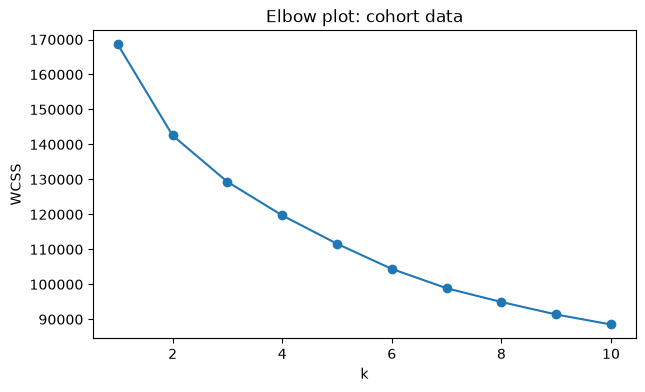

[168579.  142557.7 129306.8 119707.3 111588.4 104399.2  98876.1  94935.
  91366.4  88503.9]


In [3]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    km.fit(cohort_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow plot: cohort data")
plt.savefig("../images/clustering/elbow.png", dpi=150, bbox_inches="tight")
plt.show()
print(np.round(wcss, 1))

k = 2   silhouette = 0.174
k = 3   silhouette = 0.119
k = 4   silhouette = 0.13
k = 5   silhouette = 0.134
k = 6   silhouette = 0.126
k = 7   silhouette = 0.125
k = 8   silhouette = 0.122
k = 9   silhouette = 0.12
k = 10   silhouette = 0.114


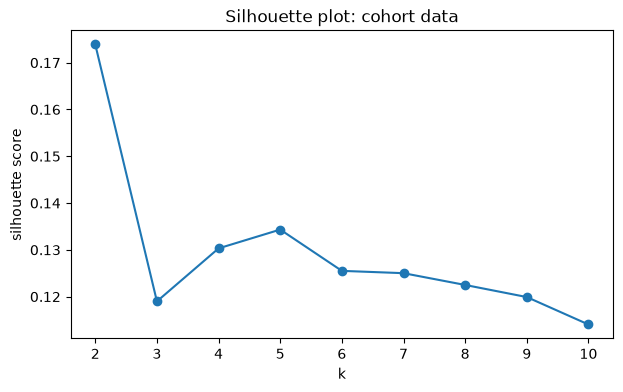

In [4]:
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit(cohort_scaled).labels_
    score = metrics.silhouette_score(cohort_scaled, labels, metric="euclidean",
                                     sample_size=5000, random_state=0)
    silhouette_scores.append(score)
    print(f"k = {k}   silhouette = {np.round(score, 3)}")

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("Silhouette plot: cohort data")
plt.savefig("../images/clustering/silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

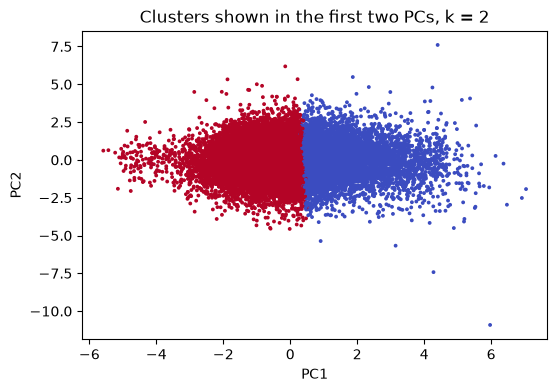

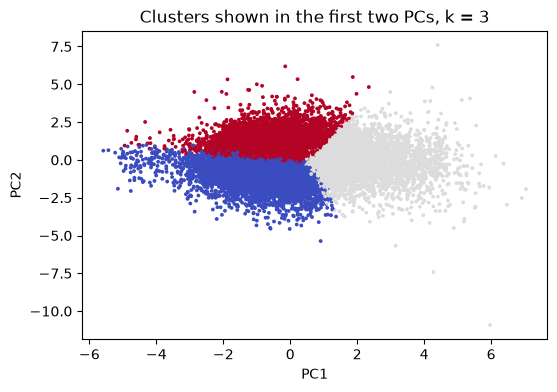

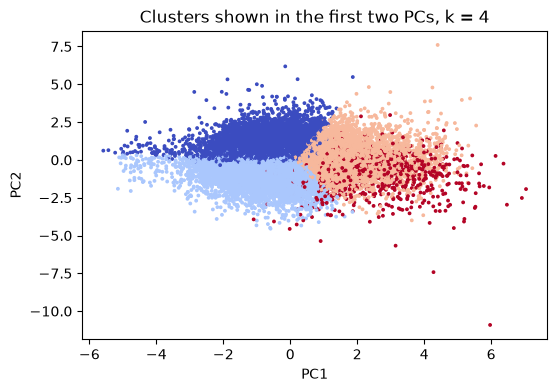

In [5]:
# PCA is used here only to draw 9 features on a flat 2-D plot
pca = decomposition.PCA(n_components=2)
pca.fit(cohort_scaled)
scores = pca.transform(cohort_scaled)
scores_df = pd.DataFrame(scores, columns=["PC1", "PC2"])

for k in range(2, 5):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    km.fit(cohort_scaled)

    plt.figure(figsize=(6, 4))
    plt.scatter(scores_df["PC1"], scores_df["PC2"], c=km.labels_, cmap="coolwarm", s=3)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Clusters shown in the first two PCs, k = {k}")
    plt.savefig(f"../images/clustering/kmeans_k{k}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
from itertools import cycle, islice
from pandas.plotting import parallel_coordinates

def kmeans_centers_pp_vis(n_clusters, n_init, random_state = 0):
    KM = KMeans(n_clusters = n_clusters, n_init=n_init, random_state=random_state)
    model = KM.fit(cohort_scaled) # fits the model to the data
    centers = model.cluster_centers_ # collects all central points of 4 clusters

    # 1. Create a function that generates a Dataframe with a cluster Number Column 

    def pd_centers(featuresUsed, centers):
        colNames = list(featuresUsed)
        colNames.append('prediction')
        Z = [np.append(A, index) for index, A in enumerate(centers)]
        P = pd.DataFrame(Z, columns = colNames)
        P['prediction'] = P['prediction'].astype(int)
        return P

    # 1. Function that creates Parallel Plots
        
    def parallel_plots(data):
        my_colors = list(islice(cycle(['b', 'r', 'g', 'y', 'k']), None, len(data)))
        plt.figure(figsize=(15,8)).gca().axes.set_ylim([-3, +3])
        plt.title('Parallel Plots of Cluster Centers')
        plt.xticks(rotation=45)
        parallel_coordinates(data, 'prediction', color = my_colors, marker = 'o')
        plt.savefig("../images/clustering/parallel_plots.png", dpi=150, bbox_inches="tight")


    P = pd_centers(features, centers)
    parallel_plots(P)  

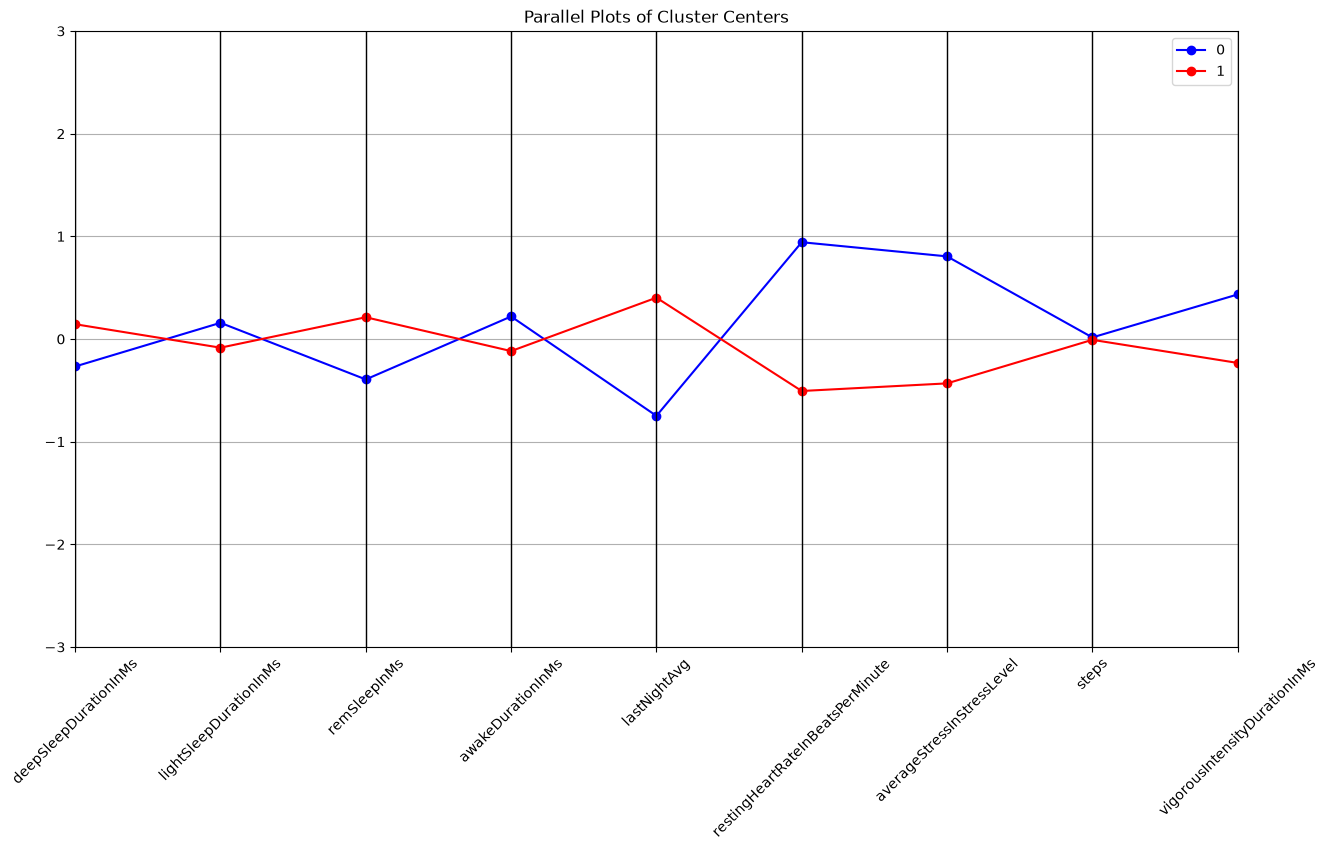

In [7]:
kmeans_centers_pp_vis(n_clusters = 2, n_init = 10, random_state = 0)

cluster
1    12172
0     6559
Name: count, dtype: int64


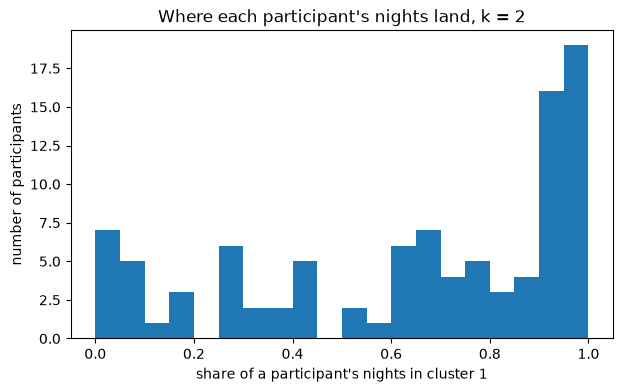

In [15]:
km2 = KMeans(n_clusters=2, n_init=10, random_state=0).fit(cohort_scaled)
cohort["cluster"] = km2.labels_
print(cohort["cluster"].value_counts())

# for each participant: the share of their nights that fall in cluster 1
share = cohort.groupby("participant_id")["cluster"].mean()

plt.figure(figsize=(7, 4))
plt.hist(share, bins=20)
plt.xlabel("share of a participant's nights in cluster 1")
plt.ylabel("number of participants")
plt.title("Where each participant's nights land, k = 2")
plt.savefig("../images/clustering/participant_share_k2.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# average each participant's nights into a single row
participants = cohort.groupby("participant_id")[features].mean()
print("shape:", participants.shape)

participants_scaled = StandardScaler().fit_transform(participants)
participants_scaled = pd.DataFrame(participants_scaled, columns=features, index=participants.index)
participants_scaled.head()

shape: (98, 9)


,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,lastNightAvg,restingHeartRateInBeatsPerMinute,averageStressInStressLevel,steps,vigorousIntensityDurationInMs
participant_id,,,,,,,,,
P1,0.148851,-0.229546,-0.713293,-1.195030,1.306211,-1.269690,0.362561,0.142403,-0.386468
P10,1.775158,0.002376,0.402885,-0.306529,-0.707836,0.853513,0.909529,0.354173,0.276373
P11,0.777988,1.774240,1.639964,-1.023230,-1.333491,1.496915,0.668494,0.269104,0.527641
P12,-0.334783,1.069722,1.167318,0.473385,-0.110258,0.832214,-0.912881,-0.226347,-0.792978
P13,-0.056488,0.439061,0.214385,1.393357,-0.875081,1.244364,-0.558946,-2.055890,-0.326224


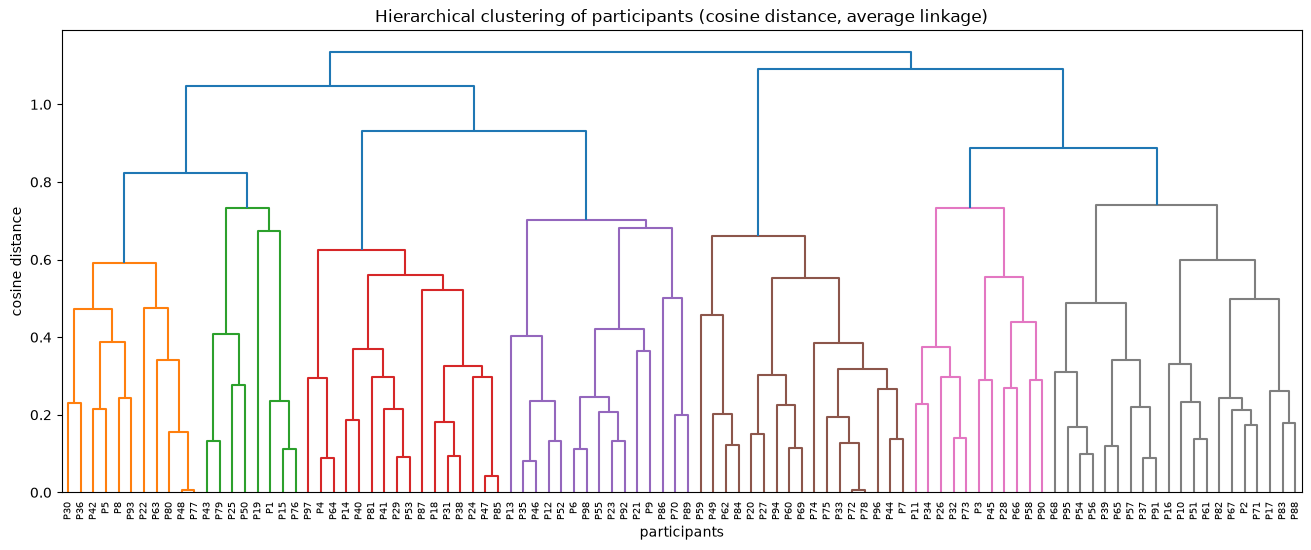

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# build the tree: start with 98 separate participants and keep merging the two closest groups
tree = linkage(participants_scaled, method="average", metric="cosine")

plt.figure(figsize=(16, 6))
dendrogram(tree, labels=participants_scaled.index.tolist(), leaf_rotation=90, leaf_font_size=7)
plt.ylabel("cosine distance")
plt.xlabel("participants")
plt.title("Hierarchical clustering of participants (cosine distance, average linkage)")
plt.savefig("../images/clustering/dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# heights of the last 8 merges, from the top down
print("The heights of the last 8 merges, from the top down:", np.round(tree[-8:, 2][::-1], 3),"\n")
#distances between cuts:
print("The distances between the last 8 cuts, from the top down:", abs(np.round(np.diff(tree[-8:, 2][::-1]), 3)), "\n")
print("The largest distance is:", np.round(np.max(abs(np.diff(tree[-8:, 2][::-1]))), 3),"and its cluster level is", np.argmax(abs(np.diff(tree[-8:, 2][::-1])))+2)

# cut the tree into 2 groups (for comparision with silhouette score) and into 4 groups
participants["Hierarchical Clustering - 2"] = fcluster(tree, t=2, criterion="maxclust")
participants["Hierarchical Clustering - 4"] = fcluster(tree, t=4, criterion="maxclust")


# k-means on the same 98 participants
participants["KMeans - 2"] = KMeans(n_clusters=2, n_init=10, random_state=0).fit(participants_scaled).labels_
participants["KMeans - 4"] = KMeans(n_clusters=4, n_init=10, random_state=0).fit(participants_scaled).labels_

table_2 = pd.crosstab(participants["Hierarchical Clustering - 2"], participants["KMeans - 2"])
table_4 = pd.crosstab(participants["Hierarchical Clustering - 4"], participants["KMeans - 4"])

print("Tree vs KMeans (k=2):\n")
print(table_2)
print("\nThe alignment percentage between Tree and KMeans (k=2) is:")
print(np.round((max(table_2.iloc[1])+max(table_2.iloc[0])) / (table_2.sum().sum()),3)*100, "%\n\n") #take the max in each row, sum them, divide by total participants

print("Tree vs KMeans (k=4):\n")
print(table_4)
print("\nThe alignment percentage between Tree and KMeans (k=4) is:")
print(np.round((max(table_4.iloc[0])+max(table_4.iloc[1])+max(table_4.iloc[2])+max(table_4.iloc[3])) / table_4.sum().sum(),3)*100, "%\n\n") #take the max in each row, sum them, divide by total participants


The heights of the last 8 merges, from the top down: [1.134 1.092 1.047 0.932 0.888 0.824 0.74  0.734] 

The distances between the last 8 cuts, from the top down: [0.042 0.046 0.115 0.044 0.064 0.084 0.006] 

The largest distance is: 0.115 and its cluster level is 4
Tree vs KMeans (k=2):

KMeans - 2                    0   1
Hierarchical Clustering - 2        
1                            15  35
2                            26  22

The alignment percentage between Tree and KMeans (k=2) is:
62.2 %


Tree vs KMeans (k=4):

KMeans - 4                    0   1   2   3
Hierarchical Clustering - 4                
1                             0  17   1   1
2                             0   8  23   0
3                            15   0   1   1
4                             0   0   2  29

The alignment percentage between Tree and KMeans (k=4) is:
85.7 %




Hierarchical Clustering - 4
1    19
2    31
3    17
4    31
Name: count, dtype: int64
Hierarchical Clustering - 4          1     2     3     4
deepSleepDurationInMs             0.22 -0.79 -0.37  0.86
lightSleepDurationInMs           -0.52  0.52  0.44 -0.45
remSleepInMs                     -0.83  0.44 -0.57  0.38
awakeDurationInMs                -0.06  0.37  0.40 -0.55
lastNightAvg                      0.83  0.51 -0.95 -0.50
restingHeartRateInBeatsPerMinute -0.56 -0.41  1.22  0.09
averageStressInStressLevel        0.10 -0.64  1.32 -0.15
steps                             0.38 -0.43 -0.22  0.31
vigorousIntensityDurationInMs    -0.11 -0.40  1.31 -0.25


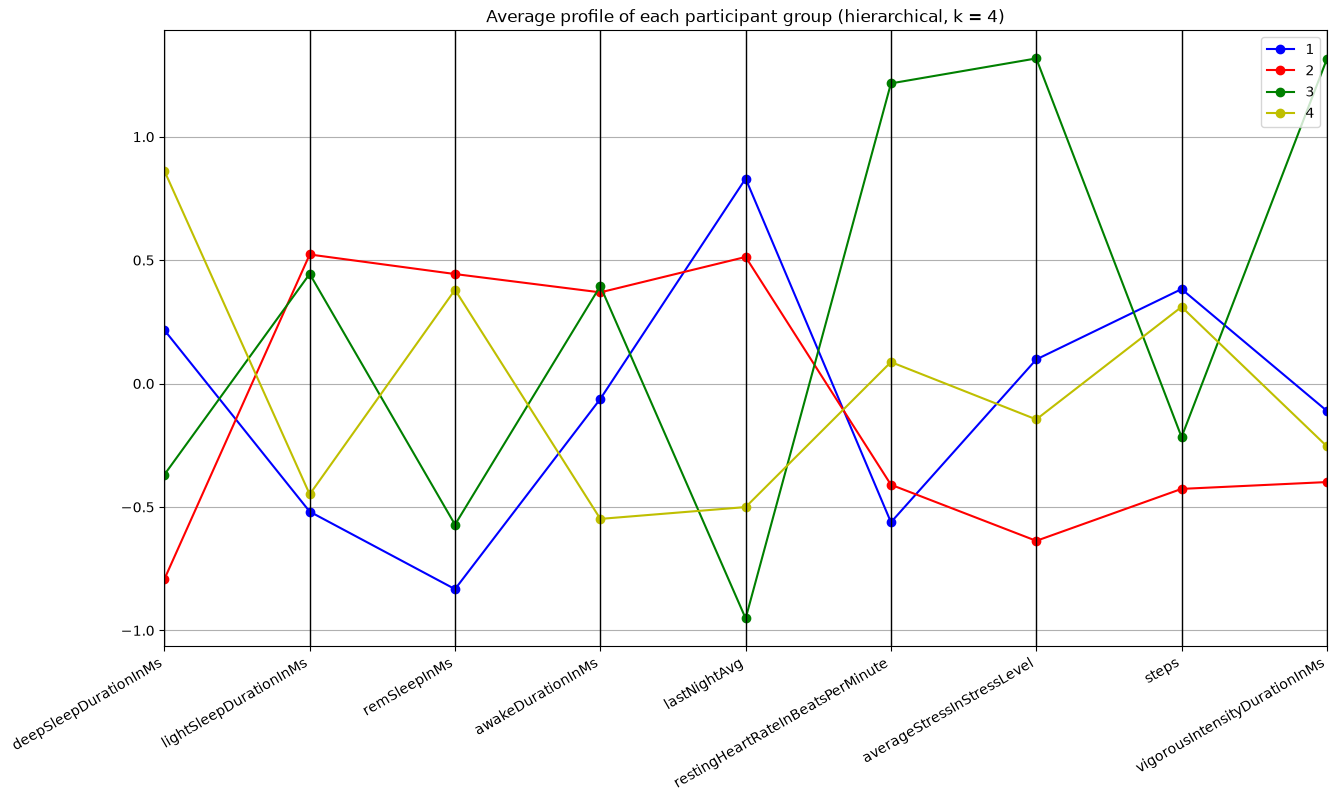

In [12]:
# how many people in each group
print(participants["Hierarchical Clustering - 4"].value_counts().sort_index())

# average scaled profile of each group
group_means = participants_scaled.groupby(participants["Hierarchical Clustering - 4"]).mean()
print(group_means.round(2).T)

plot_table = group_means.reset_index()
plt.figure(figsize=(15, 8))
parallel_coordinates(plot_table, "Hierarchical Clustering - 4", color=["b", "r", "g", "y"], marker="o")
plt.xticks(rotation=30, ha="right")
plt.title("Average profile of each participant group (hierarchical, k = 4)")
plt.savefig("../images/clustering/participant_groups_k4.png", dpi=150, bbox_inches="tight")
plt.show()